In [36]:
# import libraries
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [37]:
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [38]:
block_size = 8

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])  
Xte,  Yte  = build_dataset(words[n2:])  

In [39]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

In [40]:
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # initialize parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
        if x.ndim == 2:
            dim = 0
        elif x.ndim == 3:
            dim = (0, 1)
        xmean = x.mean(dim, keepdims=True)
        xvar = x.var(dim, keepdims=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

In [41]:
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [65]:
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

In [66]:
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []

In [67]:
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []

In [68]:
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [69]:
# initialization
n_embd = 24
n_hidden = 128
torch.manual_seed(42)

model = Sequential([
    Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1
    for layer in model.layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0 #5/3

print(sum(p.nelement() for p in model.parameters()))
for p in model.parameters():
    p.requires_grad = True

76579


In [70]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) 
  
  # backward pass
  # for layer in layers:
  #   layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in model.parameters():
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01
  for p in model.parameters():
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  # with torch.no_grad():
  #   ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  # if i >= 999:
  #   break # AFTER_DEBUG: would take out to run full optimization

      0/ 200000: 3.3156
  10000/ 200000: 2.1797
  20000/ 200000: 2.1186
  30000/ 200000: 2.4698
  40000/ 200000: 2.2306
  50000/ 200000: 1.8119
  60000/ 200000: 2.2508
  70000/ 200000: 1.9866
  80000/ 200000: 1.7589
  90000/ 200000: 1.9041
 100000/ 200000: 1.8425
 110000/ 200000: 2.0612
 120000/ 200000: 1.8128
 130000/ 200000: 1.9624
 140000/ 200000: 1.8869
 150000/ 200000: 1.8638
 160000/ 200000: 1.8495
 170000/ 200000: 1.6125
 180000/ 200000: 1.6841
 190000/ 200000: 2.0561


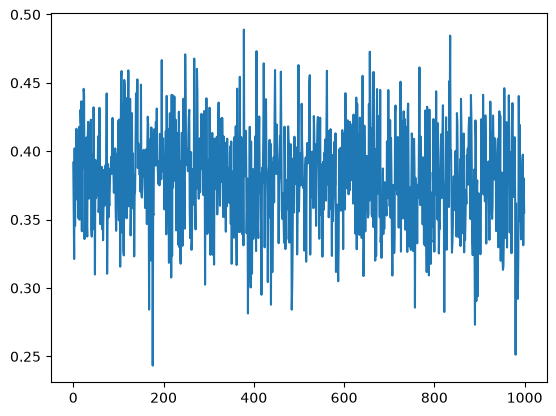

In [57]:
plt.plot(lossi)

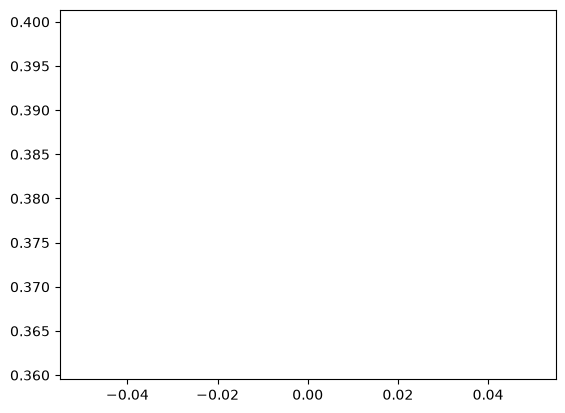

In [58]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [71]:
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

In [72]:
# Calculate loss
@torch.no_grad()
def split_loss(split):
    x, y = {'train': [Xtr, Ytr],
            'dev': [Xdev, Ydev],
            'test': [Xte, Yte]}[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y) 
    print(loss)

In [74]:
split_loss('train')
split_loss('dev')

tensor(1.8092)
tensor(1.9868)


In [75]:
# inference
with torch.no_grad():
    for _ in range(10):
        out = []
        context = [0] * block_size
    
        while True:
            x = torch.tensor([context])
            logits = model(x)
            
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1).item()
            context = context[1:] + [ix]
            out.append(itos[ix])
            if ix == 0:
                break
    
        print(''.join(out))

apoljoe.
otzayara.
zaraciya.
meharjwan.
amylie.
broxcie.
geari.
anslibet.
absarah.
astaniya.


In [51]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb = Xtr[ix]
logits = model.layers[0](Xb)
logits.shape
torch.cat([logits[:, ::2, :], logits[:, 1::2, :]], dim=2) == logits.view(4, 4, 20)

tensor([[[True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [T